In [ ]:
import pennylane as qml
from executor import Executor, QuantumCircuit, QuantumOperator, Parameters
%matplotlib inline

In [ ]:
x = Parameters("x", 1)
p = Parameters("p", 2)

qc = QuantumCircuit(2)
qc.h(0)
qc.ryy(0, 1, p[0] * x[0])

In [ ]:
pop = Parameters("pop", 2)
operator = QuantumOperator(["ZI", "IZ"], [pop[0], pop[1]])

(<Figure size 500x300 with 1 Axes>, <Axes: >)

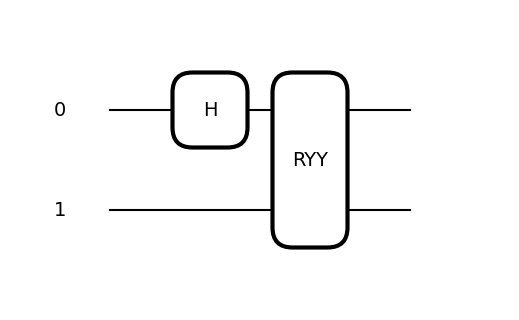

In [ ]:
executor = Executor.create("pennylane", seed=0, shots=10000)

pennylane_circuit = executor.transpile_circuit(qc)
qml.draw_mpl(
    qml.QNode(pennylane_circuit.build_pennylane_circuit(), qml.device("default.qubit", wires=2))
)([1.0], [0.5])

In [ ]:
result = executor.expectation_value(
    pennylane_circuit,
    operator,
    x=[0.1],
    p=[0.3],
    pop=[0.5, 0.6],
)
print("Expectation value:", result)

Expectation value: 0.5997300202493929


In [ ]:
v = executor.expectation_value_derivatives(
    pennylane_circuit,
    operator,
    "x",
    "p",
    "pop",
    x=[0.1],
    p=[0.3],
    pop=[0.5, 0.6],
)
print(v)

{'p': array([-0.00179973]), 'pop': array([0.        , 0.99955003]), 'x': array([-0.00539919])}


c:\Users\mow\Documents\dev\Executor\.venv\Lib\site-packages\pennylane\_grad\grad.py:628: PennyLaneDeprecationWarning: argnum in qml.jacobian has been renamed to argnums to match jax and catalyst.
  warnings.warn(


In [ ]:
executor.statevector(
    pennylane_circuit,
    x=[0.8],
    p=[0.5],
)

array([0.69301172+0.j        , 0.        -0.14048043j,
       0.69301172+0.j        , 0.        +0.14048043j])

In [ ]:
executor.sample(
    pennylane_circuit,
    x=[0.8],
    p=[0.5],
)

c:\Users\mow\Documents\dev\Executor\.venv\Lib\site-packages\pennylane\devices\device_api.py:201: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


[{'10': 4815, '00': 4810, '11': 195, '01': 180}]